# Explore Musique SFT datasets

Joins `data/sft/musique_onpolicy/*.jsonl` and `data/sft/musique_nosearch/nosearch_sft.jsonl` against the natural-paraphrase and parametric-uncertainty sidecars to recover per-example `example_id` / `hop_index`, plots hop-count distributions, and scans assistant content for pipeline contamination (validation errors, empty think blocks, truncation).

In [1]:
import json, re, os
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('/home/dvirla/projects/parametric_search_tradeoff')
DATA = ROOT / 'data'
SFT_ONPOLICY = DATA / 'sft' / 'musique_onpolicy'
SFT_NOSEARCH = DATA / 'sft' / 'musique_nosearch'
OUT = ROOT / 'results' / 'sft_exploration'
OUT.mkdir(parents=True, exist_ok=True)

ONPOLICY_FILES = {
    'raw': SFT_ONPOLICY / 'procedure1_onpolicy_sft.jsonl',
    'curated': SFT_ONPOLICY / 'procedure1_onpolicy_sft_curated.jsonl',
    'curated_llm': SFT_ONPOLICY / 'procedure1_onpolicy_sft_curated_llm.jsonl',
}
NOSEARCH_FILE = SFT_NOSEARCH / 'nosearch_sft.jsonl'
NATURAL_JSONL = DATA / 'musique_train_natural.jsonl'
# This dataset concerns only Nemotron — use the Nemotron uncertainty file alone.
UNCERTAINTY_FILES = [
    ('nemotron', ROOT / 'results/musique_parametric/musique_parametric_uncertainty_nemotron-3-nano_30b.json'),
]

def norm(s: str) -> str:
    return re.sub(r'\s+', ' ', (s or '').strip().lower())

# Musique IDs include '2hop__', '3hop1__', '4hop2__' — allow optional digit
# suffix between 'hop' and the double-underscore.
def hop_count_from_id(example_id: str) -> int | None:
    m = re.match(r'^(\d+)hop\d*__', example_id or '')
    return int(m.group(1)) if m else None

def load_jsonl(path):
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

print('OK')

OK


## 1. Load sidecars and build lookup tables

In [2]:
natural = load_jsonl(NATURAL_JSONL)
print(f'natural rows: {len(natural)}')
natural_df = pd.DataFrame([
    {'example_id': r['example_id'], 'reasoning_hops': r.get('reasoning_hops'),
     'text': r['text'], 'original_question': r.get('original_question')}
    for r in natural
])
natural_df['hops_from_id'] = natural_df['example_id'].map(hop_count_from_id)
mismatch = (natural_df['reasoning_hops'] != natural_df['hops_from_id']).sum()
print(f'reasoning_hops != hops_from_id: {mismatch}')
natural_by_text = {norm(r['text']): {'example_id': r['example_id'], 'reasoning_hops': r.get('reasoning_hops')}
                   for r in natural}
natural_df.head()

natural rows: 1500
reasoning_hops != hops_from_id: 0


,example_id,reasoning_hops,text,original_question,hops_from_id
0,2hop__146496_719024,2,I'm curious about Kara Vâsıf Bey—could you tel...,What city is the place Kara Vâsıf Bey died loc...,2
1,2hop__22156_22195,2,I'm curious about the reforms Paul wanted for ...,In what year was celibacy in the priesthood af...,2
2,2hop__42169_56335,2,I'm curious about the early stages of the Firs...,In the war that followed Joseph Schumpeter's a...,2
3,2hop__48861_621419,2,I'm curious about the person who promotes the ...,Who is the employer of the person who said the...,2
4,2hop__522617_127255,2,I'm curious about the record label Planningtor...,When was the inception of the record label of ...,2


In [3]:
# Build candidate map: norm_question -> list of {example_id, hop_index, gold_answer,
# semantic_entropy, num_correct, source}. We keep ALL candidates because the same
# normalized sub-question text can appear in multiple multi-hop problems / multiple
# model runs; we need to pick the one that satisfies the script invariant.
hop_records = []
for src, path in UNCERTAINTY_FILES:
    if not path.exists():
        print(f'  skip missing: {path}')
        continue
    blob = json.load(open(path))
    n = 0
    for prob in blob:
        eid = prob['example_id']
        for sq in prob.get('sub_questions_results', []):
            hop_records.append({
                'source': src,
                'example_id': eid,
                'hop_index': sq.get('hop_index'),
                'question': sq.get('question'),
                'gold_answer': sq.get('gold_answer'),
                'semantic_entropy': sq.get('semantic_entropy'),
                'num_correct': sq.get('num_correct'),
            })
            n += 1
    print(f'  {src}: {len(blob)} problems, {n} hop rows')
hops_df = pd.DataFrame(hop_records)
hops_df['hops_from_id'] = hops_df['example_id'].map(hop_count_from_id)
print(f'\nTotal hop rows (with duplicates across sources): {len(hops_df)}')
print(f"Unmappable hop counts (regex miss): {hops_df['hops_from_id'].isna().sum()}")
print('Prefixes:', sorted({eid.split('__')[0] for eid in hops_df['example_id']}))

hop_by_question: dict[str, list[dict]] = defaultdict(list)
for r in hop_records:
    hop_by_question[norm(r['question'])].append(r)
print(f'unique normalized sub-question keys: {len(hop_by_question)}')
hops_df.head()

  nemotron: 2100 problems, 6300 hop rows

Total hop rows (with duplicates across sources): 6300
Unmappable hop counts (regex miss): 0
Prefixes: ['2hop', '3hop1', '3hop2', '4hop1', '4hop2', '4hop3']
unique normalized sub-question keys: 3295


,source,example_id,hop_index,question,gold_answer,semantic_entropy,num_correct,hops_from_id
0,nemotron,4hop1__668178_765799_282674_759393,0,What is the place of birth of Don Werner?,Appleton,-0.000000,0,4
1,nemotron,4hop1__668178_765799_282674_759393,1,What is the capital of of Appleton?,Outagamie County,0.721928,0,4
2,nemotron,4hop1__668178_765799_282674_759393,2,What is the shares border with of Outagamie Co...,Brown County,1.921928,0,4
3,nemotron,4hop1__668178_765799_282674_759393,3,What is the capital of Brown County?,Green Bay,0.721928,0,4
4,nemotron,2hop__17192_77606,0,Who secured southern Lebanon?,Israel,1.521928,1,2


## 2. Onpolicy: load + join to natural sidecar

In [4]:
def assistant_messages(msgs):
    return [m for m in msgs if m.get('role') == 'assistant']

def count_tool_calls(msgs):
    return sum(len(m.get('tool_calls') or []) for m in assistant_messages(msgs))

def onpolicy_row(file_tag, idx, ex):
    msgs = ex['messages']
    user = next((m for m in msgs if m.get('role') == 'user'), None)
    user_content = (user or {}).get('content', '')
    match = natural_by_text.get(norm(user_content))
    return {
        'file': file_tag,
        'row_idx': idx,
        'user_content': user_content,
        'example_id': match['example_id'] if match else None,
        'reasoning_hops': match['reasoning_hops'] if match else None,
        'n_assistant_turns': len(assistant_messages(msgs)),
        'n_tool_calls': count_tool_calls(msgs),
        'n_messages': len(msgs),
    }

onpolicy_dfs = {}
for tag, path in ONPOLICY_FILES.items():
    rows = load_jsonl(path)
    df = pd.DataFrame([onpolicy_row(tag, i, ex) for i, ex in enumerate(rows)])
    onpolicy_dfs[tag] = df
    matched = df['example_id'].notna().sum()
    print(f'{tag:>12}: {len(df):4d} rows, matched {matched} ({matched/len(df):.1%})')
onpolicy_dfs['raw'].head()

         raw:  863 rows, matched 863 (100.0%)
     curated:  321 rows, matched 321 (100.0%)
 curated_llm:  542 rows, matched 542 (100.0%)


,file,row_idx,user_content,example_id,reasoning_hops,n_assistant_turns,n_tool_calls,n_messages
0,raw,0,I'm curious about the star of the movie Black ...,2hop__224365_247099,2,3,2,7
1,raw,1,I'm curious about the newspaper that put toget...,2hop__643_10984,2,5,4,11
2,raw,2,I'm curious about the newspaper that put toget...,2hop__643_10984,2,2,1,5
3,raw,3,I'm curious about the newspaper that put toget...,2hop__643_10984,2,3,2,7
4,raw,4,I'm curious about the newspaper that put toget...,2hop__643_10984,2,4,3,9


In [5]:
# Unique example_ids per file and rollouts per example_id
summary = []
for tag, df in onpolicy_dfs.items():
    s = df.dropna(subset=['example_id'])
    counts = s.groupby('example_id').size()
    summary.append({
        'file': tag,
        'rows': len(df),
        'unique_example_ids': s['example_id'].nunique(),
        'mean_rollouts_per_id': counts.mean() if len(counts) else 0,
        'max_rollouts_per_id': counts.max() if len(counts) else 0,
    })
pd.DataFrame(summary)

,file,rows,unique_example_ids,mean_rollouts_per_id,max_rollouts_per_id
0,raw,863,295,2.925424,5
1,curated,321,109,2.944954,5
2,curated_llm,542,187,2.898396,5


## 3. Onpolicy: distributions

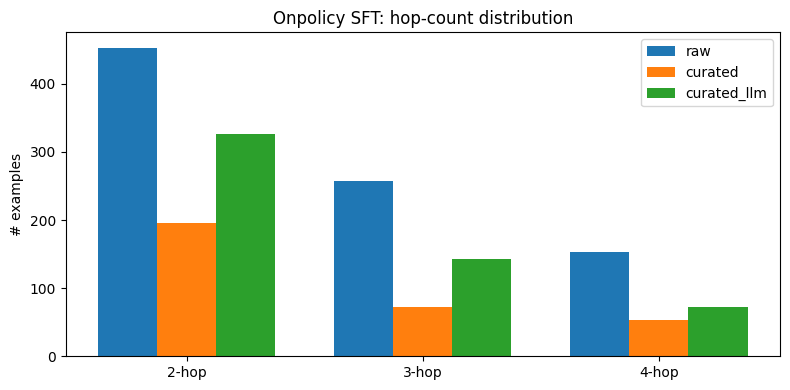

In [6]:
hops_seen = sorted({h for df in onpolicy_dfs.values() for h in df['reasoning_hops'].dropna().unique()})
files = list(onpolicy_dfs.keys())
x = np.arange(len(hops_seen))
w = 0.25
fig, ax = plt.subplots(figsize=(8,4))
for i, tag in enumerate(files):
    counts = onpolicy_dfs[tag]['reasoning_hops'].value_counts().reindex(hops_seen, fill_value=0)
    ax.bar(x + (i-1)*w, counts.values, width=w, label=tag)
ax.set_xticks(x); ax.set_xticklabels([f'{h}-hop' for h in hops_seen])
ax.set_ylabel('# examples'); ax.set_title('Onpolicy SFT: hop-count distribution')
ax.legend(); plt.tight_layout(); plt.show()

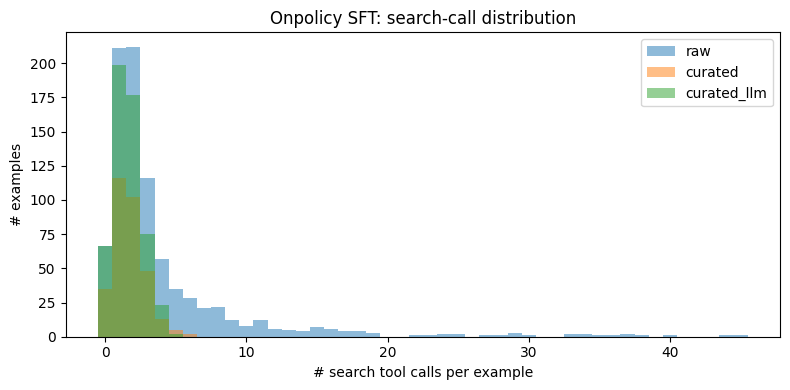

raw tool-call counts: {0: np.int64(66), 1: np.int64(211), 2: np.int64(212), 3: np.int64(116), 4: np.int64(57), 5: np.int64(35), 6: np.int64(28), 7: np.int64(21), 8: np.int64(22), 9: np.int64(12), 10: np.int64(8), 11: np.int64(12), 12: np.int64(6), 13: np.int64(5), 14: np.int64(4), 15: np.int64(7), 16: np.int64(6), 17: np.int64(4), 18: np.int64(4), 19: np.int64(3), 22: np.int64(1), 23: np.int64(1), 24: np.int64(2), 25: np.int64(2), 27: np.int64(1), 28: np.int64(1), 29: np.int64(3), 30: np.int64(1), 33: np.int64(2), 34: np.int64(2), 35: np.int64(1), 36: np.int64(1), 37: np.int64(2), 38: np.int64(1), 40: np.int64(1), 44: np.int64(1), 45: np.int64(1)}
curated tool-call counts: {0: np.int64(35), 1: np.int64(116), 2: np.int64(102), 3: np.int64(48), 4: np.int64(13), 5: np.int64(5), 6: np.int64(2)}
curated_llm tool-call counts: {0: np.int64(66), 1: np.int64(199), 2: np.int64(177), 3: np.int64(75), 4: np.int64(23), 5: np.int64(2)}


In [7]:
fig, ax = plt.subplots(figsize=(8,4))
max_calls = int(max(df['n_tool_calls'].max() for df in onpolicy_dfs.values()))
bins = np.arange(-0.5, max_calls + 1.5, 1.0)
for tag in files:
    ax.hist(onpolicy_dfs[tag]['n_tool_calls'], bins=bins, alpha=0.5, label=tag)
ax.set_xlabel('# search tool calls per example'); ax.set_ylabel('# examples')
ax.set_title('Onpolicy SFT: search-call distribution')
ax.legend(); plt.tight_layout(); plt.show()
for tag, df in onpolicy_dfs.items():
    print(tag, 'tool-call counts:', dict(df['n_tool_calls'].value_counts().sort_index()))

## 4. Nosearch: load + join to uncertainty sidecar

In [8]:
def strip_think(text: str) -> str:
    return re.sub(r'<think>.*?</think>', '', text or '', flags=re.DOTALL).strip()

def gold_in_answer(gold: str, answer: str) -> bool:
    if not gold or not answer:
        return False
    return norm(gold) in norm(answer)

def pick_candidate(cands: list[dict]) -> dict | None:
    """Pick the source the enrich script would have picked: SE<=0 & nc>0. With
    Nemotron as the sole source there is no inter-source preference; if no
    candidate satisfies the invariant we fall back to the first so the user
    still sees attribution + the flag."""
    if not cands:
        return None
    good = [c for c in cands if (c.get('semantic_entropy') or 0) <= 0
                            and (c.get('num_correct') or 0) > 0]
    pool = good or cands
    chosen = dict(pool[0])
    chosen['invariant_satisfied'] = bool(good)
    chosen['n_candidates'] = len(cands)
    return chosen

nosearch_rows = load_jsonl(NOSEARCH_FILE)
ns_records = []
for i, ex in enumerate(nosearch_rows):
    msgs = ex['messages']
    user_msg = next((m for m in msgs if m.get('role') == 'user'), None)
    asst_msg = next((m for m in msgs if m.get('role') == 'assistant'), None)
    user_q = (user_msg or {}).get('content', '')
    asst_text = (asst_msg or {}).get('content', '') or ''
    model_answer = strip_think(asst_text)
    chosen = pick_candidate(hop_by_question.get(norm(user_q), []))
    ns_records.append({
        'row_idx': i,
        'user_content': user_q,
        'model_answer': model_answer,
        'assistant_raw': asst_text,
        'example_id': (chosen or {}).get('example_id'),
        'hop_index': (chosen or {}).get('hop_index'),
        'gold_answer': (chosen or {}).get('gold_answer'),
        'semantic_entropy': (chosen or {}).get('semantic_entropy'),
        'num_correct': (chosen or {}).get('num_correct'),
        'matched_source': (chosen or {}).get('source'),
        'n_candidates': (chosen or {}).get('n_candidates'),
        'invariant_satisfied': (chosen or {}).get('invariant_satisfied'),
    })
nosearch_df = pd.DataFrame(ns_records)
nosearch_df['reasoning_hops_of_source'] = nosearch_df['example_id'].map(hop_count_from_id)
nosearch_df['answer_matches_gold'] = [gold_in_answer(g, a) for g, a in zip(nosearch_df['gold_answer'], nosearch_df['model_answer'])]
matched = nosearch_df['example_id'].notna().sum()
print(f'nosearch rows: {len(nosearch_df)}, matched {matched} ({matched/len(nosearch_df):.1%})')
nosearch_df.head()

nosearch rows: 590, matched 590 (100.0%)


,row_idx,user_content,model_answer,assistant_raw,example_id,hop_index,gold_answer,semantic_entropy,num_correct,matched_source,n_candidates,invariant_satisfied,reasoning_hops_of_source,answer_matches_gold
0,0,What is the father of John Lennon?,Alfred Lennon,<think>\nJohn Lennon was the son of Alfred Len...,2hop__797065_737459,1,Alfred Lennon,-0.0,5,nemotron,1,True,2,True
1,1,What year did The New York Times start?,1851,<think>\nThe New York Times was founded and be...,2hop__643_10984,1,1851,-0.0,5,nemotron,1,True,2,True
2,2,In what city did Fra Angelico die?,Florence,<think>\nFra Angelico was an Italian Renaissan...,3hop1__624062_145979_82585,1,Rome,-0.0,5,nemotron,5,True,3,False
3,3,when did Rome begin following a monotheistic r...,The Roman Empire began following a monotheisti...,<think>\nThe Roman Empire was originally polyt...,3hop1__624062_145979_82585,2,380,-0.0,3,nemotron,2,True,3,True
4,4,Which London museum is prominently located in ...,The National Gallery,<think>\nTrafalgar Square in London is home to...,3hop1__26417_449353_82365,0,the National Gallery,-0.0,5,nemotron,1,True,3,True


## 5. Nosearch: distributions and invariants

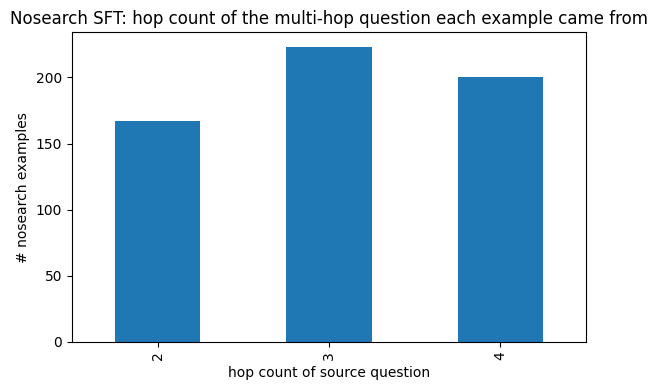

In [9]:
ax = nosearch_df['reasoning_hops_of_source'].value_counts().sort_index().plot.bar(figsize=(6,4))
ax.set_xlabel('hop count of source question'); ax.set_ylabel('# nosearch examples')
ax.set_title('Nosearch SFT: hop count of the multi-hop question each example came from')
plt.tight_layout(); plt.show()

hop_index                  0   1   2   3
reasoning_hops_of_source                
2                         73  94   0   0
3                         57  84  82   0
4                         42  44  45  69


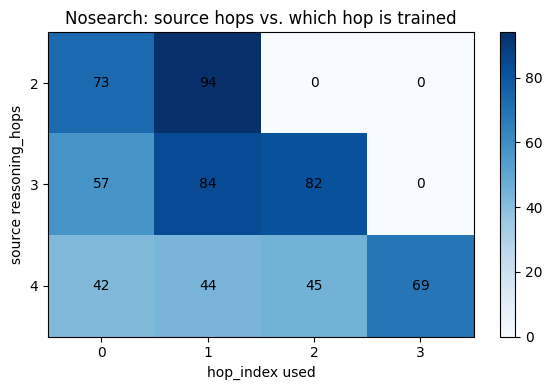

In [10]:
ct = pd.crosstab(nosearch_df['reasoning_hops_of_source'], nosearch_df['hop_index'], dropna=False)
print(ct)
fig, ax = plt.subplots(figsize=(6,4))
im = ax.imshow(ct.values, aspect='auto', cmap='Blues')
ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels([str(c) for c in ct.columns])
ax.set_yticks(range(len(ct.index))); ax.set_yticklabels([str(i) for i in ct.index])
ax.set_xlabel('hop_index used'); ax.set_ylabel('source reasoning_hops')
ax.set_title('Nosearch: source hops vs. which hop is trained')
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, int(ct.values[i, j]), ha='center', va='center', color='black')
fig.colorbar(im); plt.tight_layout(); plt.show()

In [11]:
# Construction invariants: enrich_sft_nosearch.py only emits a sub-question if
# at least one model's uncertainty file had SE<=0 AND num_correct>0 for it.
matched_df = nosearch_df.dropna(subset=['example_id']).copy()
inv_fail = matched_df[~matched_df['invariant_satisfied'].fillna(False)]
print(f'rows where NO candidate source satisfied SE<=0 & nc>0: {len(inv_fail)}')
print(f'rows where the picked candidate has SE>0: {(matched_df["semantic_entropy"].fillna(0) > 0).sum()}')
print(f'rows where the picked candidate has nc==0: {(matched_df["num_correct"].fillna(0) == 0).sum()}')
print(f'answer-gold substring agreement (model answer contains gold): {matched_df["answer_matches_gold"].mean():.1%}')
print(f'mean #candidate sources per nosearch question: {matched_df["n_candidates"].mean():.2f}')
if len(inv_fail):
    display(inv_fail.head(5)[['user_content','semantic_entropy','num_correct','gold_answer','matched_source']])

rows where NO candidate source satisfied SE<=0 & nc>0: 0
rows where the picked candidate has SE>0: 0
rows where the picked candidate has nc==0: 0
answer-gold substring agreement (model answer contains gold): 72.9%
mean #candidate sources per nosearch question: 2.70


## 6. Contamination scan (assistant content only)

In [12]:
# Two scan layers:
#   (A) per-assistant-message text patterns (works for nosearch + onpolicy)
#   (B) structural checks across the whole trace — only meaningful for onpolicy
#       because nosearch is a single assistant turn with no tool calls.
#
# We separate "contamination" (pipeline artifacts that pollute training signal)
# from "informational" findings (legitimate real-world events, e.g. search
# returning zero hits, that the user may still want to count).
#
# Patterns are tight: substrings like "raise " or "forbidden" produced false
# positives on legit phrasing inside search-result snippets ("raise the drinking
# age", "Verbotene Liebe", "unauthorized immigrants"). Tool-error patterns are
# only checked on tool messages that are NOT a JSON list of results — real
# Brave/Tavily errors come back as plaintext or a single dict, not a `[...]`.
ERROR_PATTERNS = [
    'validation error for ',
    'validationerror',
    'pydantic_core',
    'pydantic.errors',
    'traceback (most recent call last)',
    'please retry',
    'final_result is required',
    'fix your mistakes',
    'tool call validation',
]
TOOL_ERROR_PATTERNS = [
    'rate limit', 'rate_limit_exceeded',
    'unauthorized', 'forbidden', '403 forbidden', '401 unauthorized',
    'internal server error', '500 internal',
    'timeout', 'timed out',
    'brave search api error', 'tavily error', 'search api error',
    "{'error':", '{"error":',
    'connection refused', 'connection reset',
]
CONTAMINATION_FLAGS = {
    'unclosed_think', 'empty_think', 'validation_error', 'truncated',
    'null_content', 'asst_empty_no_calls', 'orphan_tool_call',
    'toolcall_no_args', 'toolcall_bad_json', 'tool_null_content',
    'tool_empty', 'tool_error',
}
INFO_FLAGS = {
    'tool_empty_results',
    'empty_final_answer',
}

def flag_assistant(content: str) -> list[str]:
    flags = []
    if content is None:
        return ['null_content']
    c = content
    cl = c.lower()
    if '<think>' in c:
        if '</think>' not in c:
            flags.append('unclosed_think')
        else:
            body = c.split('<think>', 1)[1].split('</think>', 1)[0]
            if not body.strip():
                flags.append('empty_think')
    for p in ERROR_PATTERNS:
        if p in cl:
            flags.append('validation_error'); break
    stripped = c.strip()
    if len(stripped) < 5:
        flags.append('truncated')
    elif stripped.endswith('<think') or stripped.endswith('</think') or stripped.endswith('<'):
        flags.append('truncated')
    return flags

def flag_tool_message(content: str) -> list[str]:
    flags = []
    if content is None:
        return ['tool_null_content']
    c = content
    cl = c.lower()
    stripped = c.strip()
    if not stripped:
        return ['tool_empty']
    # Brave returns a JSON list of result dicts when healthy; anything else is
    # suspect. Empty-list results are an INFO signal, not contamination.
    if stripped in ('[]', '{}'):
        flags.append('tool_empty_results')
        return flags
    looks_like_list_of_results = stripped.startswith('[') and stripped.endswith(']')
    if not looks_like_list_of_results:
        # only then is matching an error word actually a signal
        for p in TOOL_ERROR_PATTERNS:
            if p in cl:
                flags.append('tool_error'); break
        if len(stripped) < 20:
            flags.append('tool_short_result')
    return flags

def flag_tool_calls(tool_calls) -> list[str]:
    flags = []
    for tc in (tool_calls or []):
        fn = (tc.get('function') or {})
        args = fn.get('arguments')
        if args is None:
            flags.append('toolcall_no_args'); continue
        if isinstance(args, str):
            try:
                json.loads(args)
            except (json.JSONDecodeError, ValueError):
                flags.append('toolcall_bad_json')
    return flags

def scan_messages(msgs):
    all_flags = []
    asst_msgs = [m for m in msgs if m.get('role') == 'assistant']
    tool_msgs = [m for m in msgs if m.get('role') == 'tool']
    for m in asst_msgs:
        all_flags.extend(flag_assistant(m.get('content') or ''))
        all_flags.extend(flag_tool_calls(m.get('tool_calls')))
    for m in tool_msgs:
        all_flags.extend(flag_tool_message(m.get('content')))
    for m in asst_msgs:
        c = m.get('content') or ''
        if not c.strip() and not m.get('tool_calls'):
            all_flags.append('asst_empty_no_calls')
    expected_ids = {tc.get('id') for m in asst_msgs for tc in (m.get('tool_calls') or [])}
    got_ids = {m.get('tool_call_id') for m in tool_msgs}
    if expected_ids - got_ids:
        all_flags.append('orphan_tool_call')
    if asst_msgs:
        last = asst_msgs[-1].get('content') or ''
        if not strip_think(last) and not asst_msgs[-1].get('tool_calls'):
            all_flags.append('empty_final_answer')
    return all_flags

def add_contamination(df, raw_rows):
    flag_lists = [scan_messages(ex['messages']) for ex in raw_rows]
    contam = [[f for f in fl if f in CONTAMINATION_FLAGS] for fl in flag_lists]
    info   = [[f for f in fl if f in INFO_FLAGS]          for fl in flag_lists]
    df = df.copy()
    df['contamination_flags'] = [','.join(sorted(set(fl))) for fl in contam]
    df['has_contamination'] = [bool(fl) for fl in contam]
    df['info_flags'] = [','.join(sorted(set(fl))) for fl in info]
    return df, flag_lists

raw_onpolicy = {tag: load_jsonl(p) for tag, p in ONPOLICY_FILES.items()}
print('--- contamination (real pipeline artifacts) ---')
for tag in files:
    onpolicy_dfs[tag], fl = add_contamination(onpolicy_dfs[tag], raw_onpolicy[tag])
    contam_only = Counter(f for sub in fl for f in sub if f in CONTAMINATION_FLAGS)
    print(f'{tag:>12}: {dict(contam_only) or "{}"}')
nosearch_df, ns_flags = add_contamination(nosearch_df, nosearch_rows)
ns_contam = Counter(f for sub in ns_flags for f in sub if f in CONTAMINATION_FLAGS)
print(f'    nosearch: {dict(ns_contam) or "{}"}')

print('\n--- informational (real-world, not pipeline artifacts) ---')
for tag in files:
    info_only = Counter(f for ex in raw_onpolicy[tag] for f in scan_messages(ex["messages"]) if f in INFO_FLAGS)
    print(f'{tag:>12}: {dict(info_only) or "{}"}')
ns_info = Counter(f for sub in ns_flags for f in sub if f in INFO_FLAGS)
print(f'    nosearch: {dict(ns_info) or "{}"}')

--- contamination (real pipeline artifacts) ---
         raw: {'orphan_tool_call': 2}
     curated: {}


 curated_llm: {}
    nosearch: {}

--- informational (real-world, not pipeline artifacts) ---
         raw: {'tool_empty_results': 71}
     curated: {}


 curated_llm: {'tool_empty_results': 2}
    nosearch: {}


In [13]:
# Inspect first 3 offending rows for each flag in onpolicy raw
def show_offenders(df, raw, dataset_tag):
    if not df['has_contamination'].any():
        print(f'[{dataset_tag}] no flagged rows'); return
    seen_flags = set(f for fs in df['contamination_flags'] for f in fs.split(',') if f)
    for flag in sorted(seen_flags):
        hits = df[df['contamination_flags'].str.contains(rf'(?:^|,){re.escape(flag)}(?:,|$)', regex=True)]
        print(f'\n=== [{dataset_tag}] flag={flag} | n={len(hits)} ===')
        for _, row in hits.head(3).iterrows():
            idx = int(row['row_idx'])
            ex = raw[idx]
            asst = next((m for m in reversed(ex['messages']) if m.get('role') == 'assistant'), {})
            content = (asst.get('content') or '')[:400]
            print(f'  row_idx={idx} | user={(row.get("user_content") or "")[:80]!r}')
            print(f'    assistant: {content!r}')

for tag in files:
    show_offenders(onpolicy_dfs[tag], raw_onpolicy[tag], f'onpolicy/{tag}')
show_offenders(nosearch_df, nosearch_rows, 'nosearch')


=== [onpolicy/raw] flag=orphan_tool_call | n=2 ===
  row_idx=90 | user="I'm curious about the murder rate in Charles Oakley's college town back in 1990."
    assistant: "<think>\nIt seems we cannot use python tool? Actually the initial system description said there are functions, but we might be able to just compute the number manually: 114 homicides / 203,056 = approx 0.0005615. Times 100,000 equals 56.15. So about 56 per 100,000.\n\nLet's compute manually: 203,056 * 0.0005 = ~101.528; but with 114, it's a bit more, about 0.00056 -> 56.0. So yes approx 56 per 100k.\n"
  row_idx=492 | user='I\'m wondering about the state to the east of where the singer of "Hello Love" sp'
    assistant: '<think>\nWe have identified that Hank Snow died at his home in Madison, Tennessee. That is a city in Tennessee, which is a state. The question says: "the state to the east of where the singer of \'Hello Love\' spent his final days." The singer of "Hello Love" is Hank Snow. He spent his final days in T

## 7. Write CSVs

## 7. curated_llm: verify query-budget and per-hop gold coverage

The curation script (`scripts/curate_onpolicy_sft.py`) advertises two gates:

- **budget**: total search queries ≤ `N_uncertain_hops + max_extra_queries` (default 2)
- **coverage**: for every uncertain hop (`semantic_entropy > 0`), the gold answer appears (case-insensitive substring on normalized text) in at least one search result in the trace

Recompute both directly on `procedure1_onpolicy_sft_curated_llm.jsonl` and flag any violations.

In [14]:
# Index Nemotron uncertainty by example_id → list of uncertain hops
unc_by_id = {}
for src, path in UNCERTAINTY_FILES:
    if not path.exists():
        continue
    for prob in json.load(open(path)):
        eid = prob['example_id']
        uncertain = [
            {'hop_index': sq.get('hop_index'),
             'gold_answer': sq.get('gold_answer'),
             'question': sq.get('question'),
             'semantic_entropy': sq.get('semantic_entropy')}
            for sq in prob.get('sub_questions_results', [])
            if (sq.get('semantic_entropy') or 0) > 0
        ]
        unc_by_id[eid] = {
            'aggregate_question': prob.get('aggregate_question'),
            'sub_questions': prob.get('sub_questions_results', []),
            'uncertain': uncertain,
        }

def normalize_for_match(s: str) -> str:
    # Mirror scripts/curate_onpolicy_sft.py: lowercase + collapse whitespace +
    # strip leading/trailing punctuation. (Same intent as `normalize` there.)
    s = (s or '').lower()
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def extract_search_calls(msgs):
    """Return list of (assistant_msg_idx, query_str, following_tool_content)."""
    calls = []
    tool_by_id = {m.get('tool_call_id'): (m.get('content') or '')
                  for m in msgs if m.get('role') == 'tool'}
    for j, m in enumerate(msgs):
        if m.get('role') != 'assistant':
            continue
        for tc in (m.get('tool_calls') or []):
            fn = (tc.get('function') or {})
            args_raw = fn.get('arguments')
            args = args_raw if isinstance(args_raw, dict) else None
            if isinstance(args_raw, str):
                try:
                    args = json.loads(args_raw)
                except Exception:
                    args = {}
            query = (args or {}).get('query', '') if args else ''
            tool_content = tool_by_id.get(tc.get('id'), '')
            calls.append((j, query, tool_content))
    return calls

def gold_in_any_result(gold: str, tool_contents: list[str]) -> bool:
    g = normalize_for_match(gold)
    if len(g) < 3:
        return True
    blob = normalize_for_match(' '.join(tool_contents))
    return g in blob

rows = load_jsonl(ONPOLICY_FILES['curated_llm'])
verification = []
for i, ex in enumerate(rows):
    msgs = ex['messages']
    user_q = next((m['content'] for m in msgs if m.get('role') == 'user'), '')
    natural = natural_by_text.get(norm(user_q))
    eid = (natural or {}).get('example_id')
    info = unc_by_id.get(eid, {})
    uncertain = info.get('uncertain', [])
    n_unc = len(uncertain)
    sub_qs = info.get('sub_questions', [])
    n_hops_total = len(sub_qs)
    calls = extract_search_calls(msgs)
    n_queries = len(calls)
    tool_contents = [c for _, _, c in calls]
    coverage = []
    for h in uncertain:
        found = gold_in_any_result(h['gold_answer'], tool_contents)
        coverage.append({'hop_index': h['hop_index'], 'gold': h['gold_answer'], 'found': found})
    coverage_ok = all(h['found'] for h in coverage) if coverage else True
    extras = n_queries - n_unc
    verification.append({
        'row_idx': i,
        'example_id': eid,
        'reasoning_hops': (natural or {}).get('reasoning_hops'),
        'n_hops_total': n_hops_total,
        'n_uncertain': n_unc,
        'n_queries': n_queries,
        'extras_over_uncertain': extras,
        'budget_ok_strict_1': extras <= 1,
        'budget_ok_default_2': extras <= 2,
        'coverage_ok': coverage_ok,
        'missing_hops': ';'.join(str(h['hop_index']) for h in coverage if not h['found']),
    })

ver_df = pd.DataFrame(verification)
print(f'curated_llm rows: {len(ver_df)}')
print(f'  coverage_ok (every uncertain hop has gold in some result): {ver_df["coverage_ok"].sum()}/{len(ver_df)} ({ver_df["coverage_ok"].mean():.1%})')
print(f'  budget_ok @ +2 extras (script default):  {ver_df["budget_ok_default_2"].sum()}/{len(ver_df)} ({ver_df["budget_ok_default_2"].mean():.1%})')
print(f'  budget_ok @ +1 extra (tighter):          {ver_df["budget_ok_strict_1"].sum()}/{len(ver_df)} ({ver_df["budget_ok_strict_1"].mean():.1%})')
print(f'  rows with n_uncertain == 0: {(ver_df["n_uncertain"]==0).sum()}')
ver_df.head()

curated_llm rows: 542
  coverage_ok (every uncertain hop has gold in some result): 510/542 (94.1%)
  budget_ok @ +2 extras (script default):  542/542 (100.0%)
  budget_ok @ +1 extra (tighter):          460/542 (84.9%)
  rows with n_uncertain == 0: 145


,row_idx,example_id,reasoning_hops,n_hops_total,n_uncertain,n_queries,extras_over_uncertain,budget_ok_strict_1,budget_ok_default_2,coverage_ok,missing_hops
0,0,2hop__643_10984,2,2,1,1,0,True,True,True,
1,1,2hop__643_10984,2,2,1,2,1,True,True,True,
2,2,2hop__643_10984,2,2,1,3,2,False,True,True,
3,3,2hop__643_10984,2,2,1,3,2,False,True,True,
4,4,3hop1__624062_145979_82585,3,3,0,1,1,True,True,True,


In [15]:
# Cross-tab: distribution of extra queries (n_queries - n_uncertain) and
# coverage failures broken down by hop-count.
print('--- extras (n_queries - n_uncertain) histogram ---')
print(ver_df['extras_over_uncertain'].value_counts().sort_index().to_string())

print('\n--- by reasoning_hops ---')
display(ver_df.groupby('reasoning_hops').agg(
    rows=('row_idx','count'),
    coverage_pass=('coverage_ok','sum'),
    budget_pass_2=('budget_ok_default_2','sum'),
    budget_pass_1=('budget_ok_strict_1','sum'),
    mean_n_uncertain=('n_uncertain','mean'),
    mean_n_queries=('n_queries','mean'),
    mean_extras=('extras_over_uncertain','mean'),
    max_extras=('extras_over_uncertain','max'),
))

violations = ver_df[(~ver_df['coverage_ok']) | (~ver_df['budget_ok_default_2'])]
print(f'\nrows violating either gate: {len(violations)}')
if len(violations):
    display(violations[['row_idx','example_id','reasoning_hops','n_uncertain','n_queries','extras_over_uncertain','coverage_ok','missing_hops']].head(20))

# Save the per-row verification for offline inspection
ver_df.to_csv(OUT / 'curated_llm_verification.csv', index=False)
print(f"\nwrote {OUT/'curated_llm_verification.csv'}")

--- extras (n_queries - n_uncertain) histogram ---
extras_over_uncertain
0    265
1    195
2     82

--- by reasoning_hops ---


,rows,coverage_pass,budget_pass_2,budget_pass_1,mean_n_uncertain,mean_n_queries,mean_extras,max_extras
reasoning_hops,,,,,,,,
2,326,308,326,284,1.003067,1.616564,0.613497,2
3,143,138,143,120,0.818182,1.538462,0.720280,2
4,73,64,73,56,1.054795,1.821918,0.767123,2



rows violating either gate: 32


,row_idx,example_id,reasoning_hops,n_uncertain,n_queries,extras_over_uncertain,coverage_ok,missing_hops
11,11,2hop__103706_58400,2,1,2,1,False,1
12,12,2hop__103706_58400,2,1,1,0,False,1
13,13,2hop__103706_58400,2,1,1,0,False,1
14,14,2hop__103706_58400,2,1,1,0,False,1
15,15,2hop__103706_58400,2,1,1,0,False,1
23,23,2hop__129608_208796,2,1,2,1,False,1
69,69,4hop3__659125_39490_56933_831253,4,1,1,0,False,0
70,70,4hop3__659125_39490_56933_831253,4,1,1,0,False,0
71,71,4hop3__659125_39490_56933_831253,4,1,2,1,False,0
120,120,2hop__523872_79404,2,1,3,2,False,1



wrote /home/dvirla/projects/parametric_search_tradeoff/results/sft_exploration/curated_llm_verification.csv


In [16]:
all_onpolicy = pd.concat(onpolicy_dfs.values(), ignore_index=True)
onp_cols = ['file','row_idx','example_id','reasoning_hops','n_assistant_turns','n_tool_calls','n_messages',
            'contamination_flags','has_contamination','info_flags','user_content']
all_onpolicy[onp_cols].to_csv(OUT / 'onpolicy_examples.csv', index=False)

ns_cols = ['row_idx','example_id','hop_index','reasoning_hops_of_source','gold_answer','model_answer',
           'answer_matches_gold','semantic_entropy','num_correct','matched_source','n_candidates',
           'invariant_satisfied','contamination_flags','has_contamination','info_flags','user_content']
nosearch_df[ns_cols].to_csv(OUT / 'nosearch_examples.csv', index=False)

unmatched_rows = []
for tag, df in onpolicy_dfs.items():
    miss = df[df['example_id'].isna()]
    for _, r in miss.iterrows():
        unmatched_rows.append({'dataset': f'onpolicy/{tag}', 'row_idx': int(r['row_idx']), 'user_content': r['user_content']})
miss_ns = nosearch_df[nosearch_df['example_id'].isna()]
for _, r in miss_ns.iterrows():
    unmatched_rows.append({'dataset': 'nosearch', 'row_idx': int(r['row_idx']), 'user_content': r['user_content']})
pd.DataFrame(unmatched_rows).to_csv(OUT / 'unmatched.csv', index=False)

print('wrote:')
for p in sorted(OUT.glob('*.csv')):
    print(' ', p, p.stat().st_size, 'bytes')

wrote:
  /home/dvirla/projects/parametric_search_tradeoff/results/sft_exploration/curated_llm_verification.csv 28820 bytes
  /home/dvirla/projects/parametric_search_tradeoff/results/sft_exploration/nosearch_examples.csv 108053 bytes
  /home/dvirla/projects/parametric_search_tradeoff/results/sft_exploration/onpolicy_examples.csv 354989 bytes
  /home/dvirla/projects/parametric_search_tradeoff/results/sft_exploration/unmatched.csv 1 bytes
